In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 

In [2]:
DATASET = 'iris'   # 'iris' or 'wine'
GRID = 10   
ITERS = 1000
SEED = 42

np.random.seed(SEED)

In [3]:
def ensure_minisom():
    try:
        from minisom import MiniSom
        return MiniSom
    except Exception:
        print("MiniSom not found. Installing minisom via pip...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "minisom"])
        from minisom import MiniSom
        return MiniSom

In [ ]:
def run_minisom(data, labels, m=10, n=10, iters=1000, random_seed=42):
    MiniSom = ensure_minisom()
    scaler = StandardScaler()
    data_n = scaler.fit_transform(data)
    som = MiniSom(m, n, data_n.shape[1], sigma=max(m,n)/2.0, learning_rate=0.5, random_seed=random_seed)
    som.random_weights_init(data_n)
    som.train_random(data_n, iters)

    # Build U-matrix
    weights = som.get_weights()
    um = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            neigh = []
            for di in (-1,0,1):
                for dj in (-1,0,1):
                    ni, nj = i+di, j+dj
                    if 0 <= ni < m and 0 <= nj < n and not (di==0 and dj==0):
                        neigh.append(weights[ni, nj])
            if neigh:
                um[i, j] = np.mean([np.linalg.norm(weights[i,j] - q) for q in neigh])

    # Hit map and mapping
    hit_map = np.zeros((m,n), dtype=int)
    mapped = np.zeros((data_n.shape[0], 2), dtype=int)
    for idx, x in enumerate(data_n):
        w = som.winner(x)
        hit_map[w] += 1
        mapped[idx] = w

    # Majority label map
    label_map = np.full((m,n), -1)
    for i in range(m):
        for j in range(n):
            idxs = np.where((mapped[:,0]==i) & (mapped[:,1]==j))[0]
            if idxs.size > 0:
                vals, counts = np.unique(labels[idxs], return_counts=True)
                label_map[i, j] = vals[np.argmax(counts)]

    # Plots
    plt.figure(figsize=(5,5))
    plt.imshow(um.T, origin='lower')
    plt.title('MiniSom U-Matrix')
    plt.colorbar()
    plt.tight_layout()

    plt.figure(figsize=(5,5))
    plt.imshow(hit_map.T, origin='lower')
    plt.title('MiniSom Hit Map (counts)')
    plt.colorbar()
    plt.tight_layout()

    plt.figure(figsize=(5,5))
    plt.imshow(label_map.T, origin='lower')
    plt.title('MiniSom Majority Label Map')
    plt.colorbar()
    plt.tight_layout()

    # SOM projection vs PCA
    pca = PCA(n_components=2)
    data_pca = pca.fit_transform(data_n)

    mapped_x = mapped[:,0] + np.random.uniform(-0.3,0.3, size=mapped.shape[0])
    mapped_y = mapped[:,1] + np.random.uniform(-0.3,0.3, size=mapped.shape[0])

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sc1 = plt.scatter(mapped_x, mapped_y, c=labels, cmap='tab10', s=30)
    plt.title('MiniSom projection (BMU coords)')
    plt.gca().invert_yaxis()
    plt.colorbar(sc1, label='class')

    plt.subplot(1,2,2)
    sc2 = plt.scatter(data_pca[:,0], data_pca[:,1], c=labels, cmap='tab10', s=30)
    plt.title('PCA (2D) of normalized data')
    plt.colorbar(sc2, label='class')

    plt.tight_layout()
    plt.show()

In [5]:
if DATASET == 'iris':
    ds = datasets.load_iris()
elif DATASET == 'wine':
    ds = datasets.load_wine()
else:
    raise ValueError("Unknown DATASET value")

data = ds.data
labels = ds.target

== Part B: MiniSom-based SOM ==
Training MiniSom...


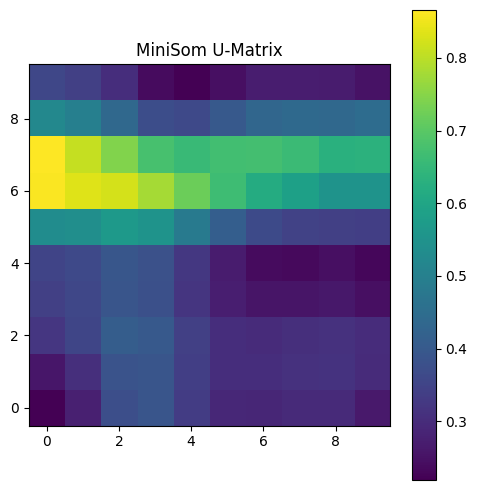

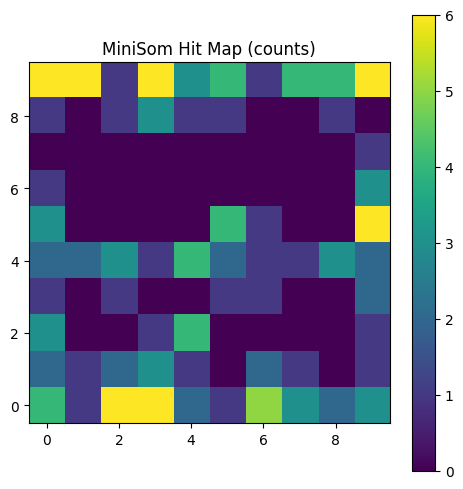

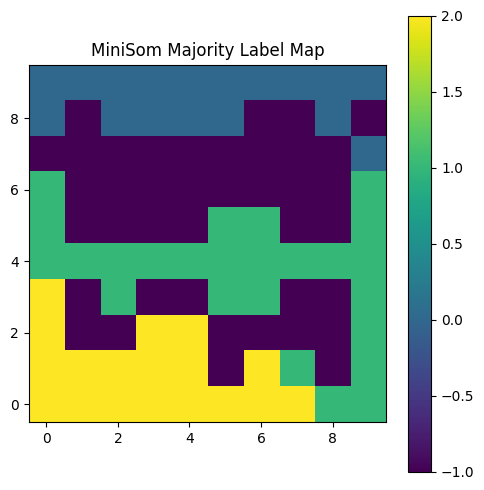

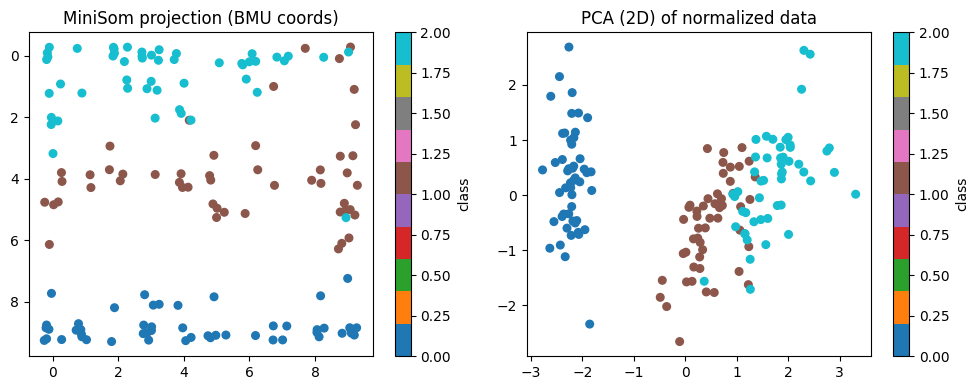

In [6]:
print("== Part B: MiniSom-based SOM ==")
run_minisom(data, labels, m=GRID, n=GRID, iters=ITERS, random_seed=SEED)